<a href="https://colab.research.google.com/github/Thangapandi1611/ml-safety-project/blob/main/week8/Visualising_the_Distribution_Shift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
from PIL import Image
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import random
import numpy as np
import cv2

In [1]:
def show_random_images(dataset_path, title, n=5):

    img_folder = os.path.join(
        dataset_path,
        "rgb-front"
    )

    images = random.sample(
        os.listdir(img_folder),
        n
    )

    plt.figure(figsize=(15,3))

    for i, img_name in enumerate(images):

        img = Image.open(
            os.path.join(
                img_folder,
                img_name
            )
        )

        plt.subplot(1,n,i+1)

        plt.imshow(img)

        plt.axis("off")

    plt.suptitle(title)

    plt.show()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
##dATA PATHS
SUNNY_PATH= "/content/drive/MyDrive/MLS/test"
FOG_PATH="/content/drive/MyDrive/MLS/test-fog"
NIGHT_PATH="/content/drive/MyDrive/MLS/test-night"
TOWN_PATH="/content/drive/MyDrive/MLS/test-town-01"

In [4]:
#Loading models
model_ped = "/content/drive/MyDrive/MLS/pedestrian_model.pth"
model_veh="/content/drive/MyDrive/MLS/Vehicle_model.pth"
model_TL="/content/drive/MyDrive/MLS/Traffic_Light_model.pth"

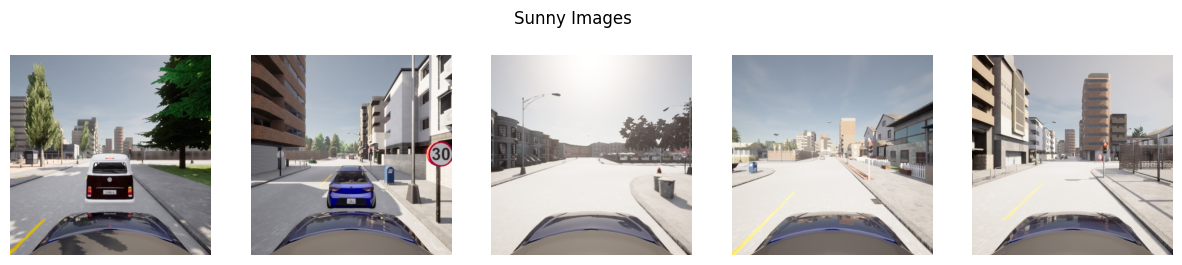

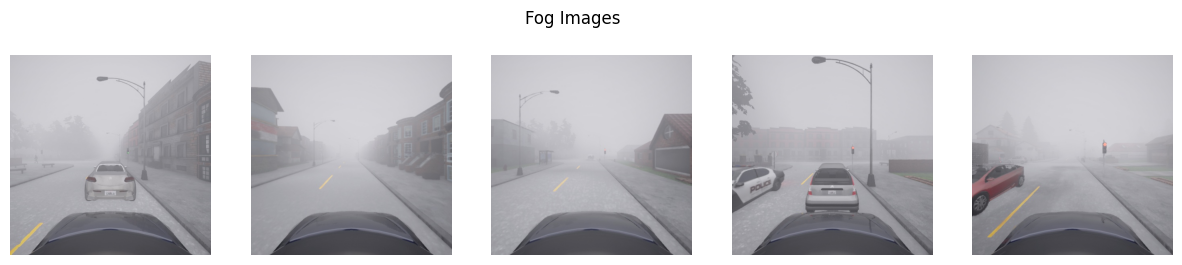

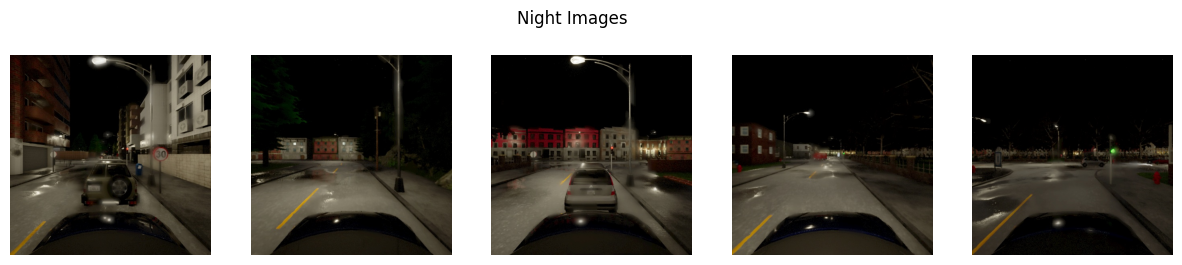

In [4]:
show_random_images(
    SUNNY_PATH,
    "Sunny Images"
)

show_random_images(
    FOG_PATH,
    "Fog Images"
)

show_random_images(
    NIGHT_PATH,
    "Night Images"
)

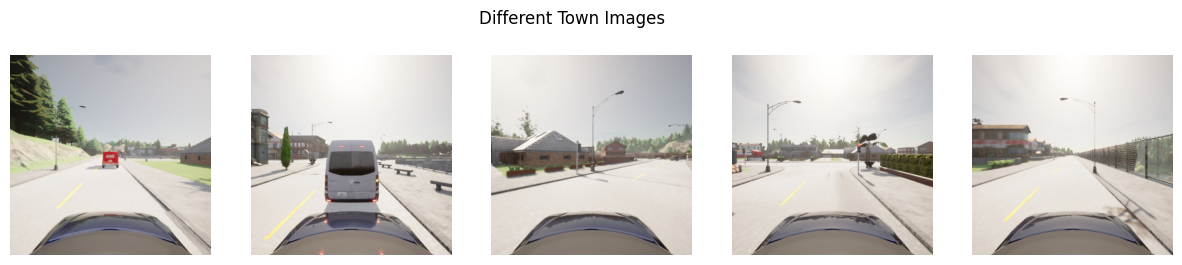

In [6]:
#Town images with Sunny,day time
show_random_images(
    TOWN_PATH,
    "Different Town Images"
)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
class CarlaDataset(Dataset):

    def __init__(self, data_path, label_column, transform=None):

        self.data_path = data_path
        self.transform = transform

        self.labels = pd.read_csv(
            os.path.join(data_path, "labels.csv")
        )

        self.label_column = label_column

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = os.path.join(
            self.data_path,
            "rgb-front",
            f"{frame}.jpg"
        )

        image = Image.open(img_path).convert("RGB")

        label = int(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
#Image Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [11]:
import torch
import numpy as np
from torch.utils.data import DataLoader

def mean_model_confidence(
    MODEL_PATH,
    DATASET_PATH,
    LABEL_COLUMN
):

    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

    model = models.resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features,1)

    model.load_state_dict(
        torch.load(
            MODEL_PATH,
            map_location=device
        )
    )

    model.to(device)

    model.eval()

    dataset = CarlaDataset(
        DATASET_PATH,
        label_column=LABEL_COLUMN,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    confidences = []
    i=0
    with torch.no_grad():

        for images, labels in loader:
            if i==100:
              break

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            confidence = torch.maximum(
                probs,
                1 - probs
            )

            confidences.extend(
                confidence.cpu()
                .numpy()
                .flatten()
            )
            i+=1

    return np.mean(confidences)

In [13]:
#Pedestrian Model
sunny_conf = mean_model_confidence(
    model_ped,
    SUNNY_PATH,
    "has_pedestrian"
)
print("Sunny :", sunny_conf)
fog_conf = mean_model_confidence(
    model_ped,
    FOG_PATH,
    "has_pedestrian"
)

night_conf = mean_model_confidence(
    model_ped,
    NIGHT_PATH,
    "has_pedestrian"
)


print("Fog   :", fog_conf)
print("Night :", night_conf)

Sunny : 0.90362626
Fog   : 0.99016404
Night : 0.9716925


In [14]:
#vehicle  Model
sunny_conf = mean_model_confidence(
    model_veh,
    SUNNY_PATH,
    "has_vehicle"
)

fog_conf = mean_model_confidence(
    model_veh,
    FOG_PATH,
    "has_vehicle"
)

night_conf = mean_model_confidence(
    model_veh,
    NIGHT_PATH,
    "has_vehicle"
)

print("Sunny :", sunny_conf)
print("Fog   :", fog_conf)
print("Night :", night_conf)

Sunny : 0.910021
Fog   : 0.82012314
Night : 0.76373136


In [15]:
#Traffic-Light model
sunny_conf = mean_model_confidence(
    model_TL,
    SUNNY_PATH,
    "has_traffic_light"
)

fog_conf = mean_model_confidence(
    model_TL,
    FOG_PATH,
    "has_traffic_light"
)

night_conf = mean_model_confidence(
    model_TL,
    NIGHT_PATH,
    "has_traffic_light"
)

print("Sunny :", sunny_conf)
print("Fog   :", fog_conf)
print("Night :", night_conf)

Sunny : 0.95855623
Fog   : 0.82163984
Night : 0.8852353
